In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# Orthogonal Polarizer axes - analysis 

In [2]:
medicion = pd.read_csv('Measurements\\medicion_manual_polarimetro_ortogonal.csv')
I_med_orth= medicion['voltaje']-0.00194
theta_orth = medicion['angulo']*np.pi/180
medicion.head()

,voltaje,angulo
0,0.003218,0
1,0.006484,10
2,0.011864,20
3,0.014984,30
4,0.014939,40


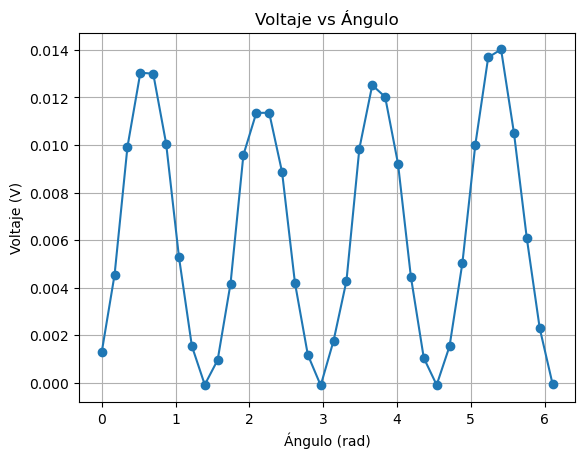

In [3]:
#we plot the data to see if it looks like a sinusoidal function, as we expect
plt.plot(theta_orth, I_med_orth, 'o-')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

In [4]:
#we calculate the first minimum
min_idx = None

for i in range(1, len(I_med_orth)-1):
    if I_med_orth[i] < I_med_orth[i-1] and I_med_orth[i] < I_med_orth[i+1]:
        min_idx = i
        break

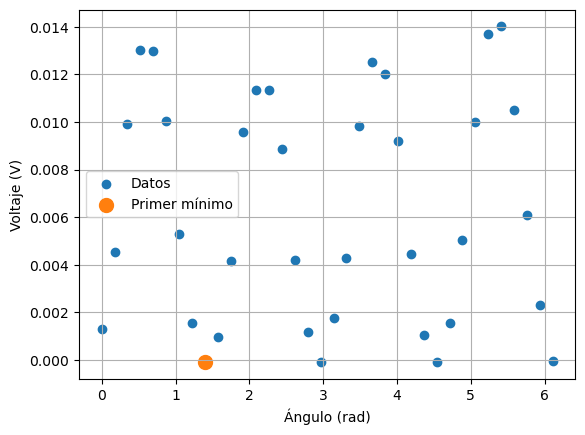

In [5]:
#we make sure we are defining correctly the lowest voltage
import matplotlib.pyplot as plt

plt.scatter(theta_orth, I_med_orth, label="Datos")

# marcar el mínimo
plt.scatter(theta_orth[min_idx], I_med_orth[min_idx],
            marker='o', s=100, label="Primer mínimo")

plt.xlabel("Ángulo (rad)")
plt.ylabel("Voltaje (V)")
plt.legend()
plt.grid()
plt.show()

In [6]:
print(min_idx)

8


In [7]:
theta_orth = theta_orth - theta_orth[min_idx]

In [8]:
#finally 
theta_orth = theta_orth[min_idx:].reset_index(drop=True)
I_med_orth = I_med_orth[min_idx:].reset_index(drop=True)

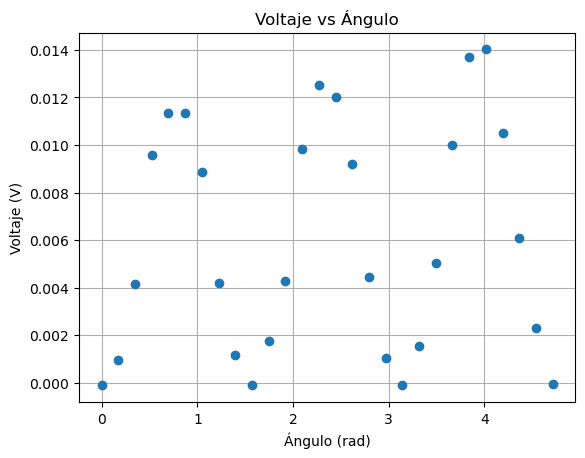

In [9]:
#we plot the data to see if it looks like a sinusoidal function, as we expect
plt.plot(theta_orth, I_med_orth, 'o')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

In [10]:
#--- estimate S0 --- and normalize voltaje 
# # --- Identify peaks in the voltage data to select the mean as the normalization factor --- 
peaks_volt = find_peaks(I_med_orth)[0] 
peaks_angle = theta_orth[peaks_volt] 
norm_number = I_med_orth[peaks_volt].mean() 
display(f'Normalization number: {norm_number}') 
I_med = I_med_orth / norm_number

'Normalization number: 0.012632266666666664'

In [11]:
S0_orth = np.max(I_med_orth)
print(f'S0: {S0_orth}')

S0: 0.014021599999999999


S0 = 0.014021599999999999
S1 = -0.014021599999999997
S2 = -0.00013573653503974565
S3 = -0.00031141591394701713

Deltas:
d1 = 3.950690149890785
d2 = 3.8481925694413497
d3 = 3.180308148582655
d4 = 1.5707963267948966

DOP = 1.0002934492810283


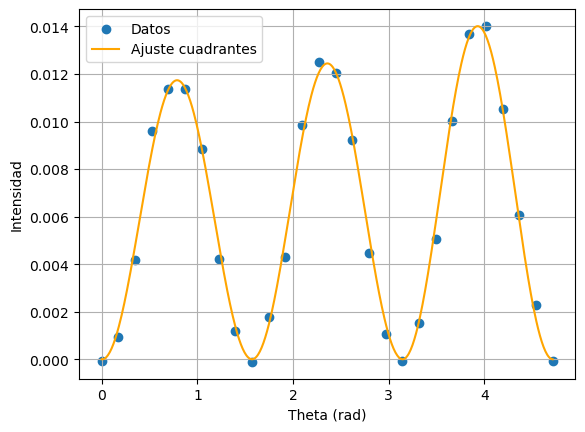

In [12]:

# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0_orth/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return model(theta_orth, S1, S2, S3, d1, d2, d3, d4) - I_med_orth

# --- initial conditions ---
initial_guess = [
    0.1*S0_orth,  # S1
    0.1*S0_orth,  # S2
    0.1*S0_orth,  # S3
    np.pi/2, np.pi/2, np.pi/2, np.pi/2  # deltas
]

# --- bounds (KEY for stability) ---
lower_bounds = [
    -S0_orth, -S0_orth, -S0_orth,
    0, 0, 0, 0
]

upper_bounds = [
    S0_orth, S0_orth, S0_orth,
    2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi
]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

print("S0 =", S0_orth)
print("S1 =", S1_fit)
print("S2 =", S2_fit)
print("S3 =", S3_fit)

print("\nDeltas:")
print("d1 =", d1_fit)
print("d2 =", d2_fit)
print("d3 =", d3_fit)
print("d4 =", d4_fit)

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0_orth
print("\nDOP =", DOP)

# --- fitted curve ---
theta_fit = np.linspace(theta_orth.min(), theta_orth.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- graph ---
plt.scatter(theta_orth, I_med_orth, label="Datos")
plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

In [13]:
#we can also plot the points on the Poincare sphere

def plot_poincare_sphere(ax, s_fit):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    ax.scatter(s_fit[0], s_fit[1], s_fit[2], s=90, label="Fitted point")
    ax.plot([0, s_fit[0]], [0, s_fit[1]], [0, s_fit[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()



[-1.         -0.00968053 -0.02220973]


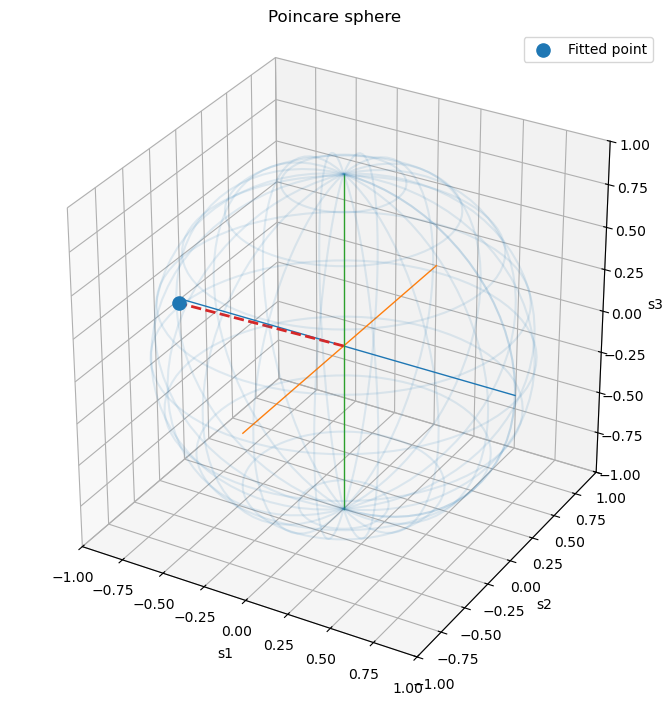

In [14]:
fig_new = plt.figure(figsize=(7, 7))
s_fit_orth=np.array([S1_fit/S0_orth , S2_fit/S0_orth , S3_fit/S0_orth ] )
print(s_fit_orth)
ax_new = fig_new.add_subplot(111, projection='3d')
plot_poincare_sphere(ax_new,  s_fit_orth)
plt.tight_layout()
plt.show()

# Parallel polarizer axes - Analysis

In [15]:
medicion = pd.read_csv('Measurements\\medicion_manual_polarimetro_paralelo.csv')
I_med_para = medicion['voltaje']-0.00194
theta_para = medicion['angulo']*np.pi/180
medicion.head()

,voltaje,angulo
0,0.069970,0
1,0.062231,10
2,0.053607,20
3,0.039862,30
4,0.034066,40


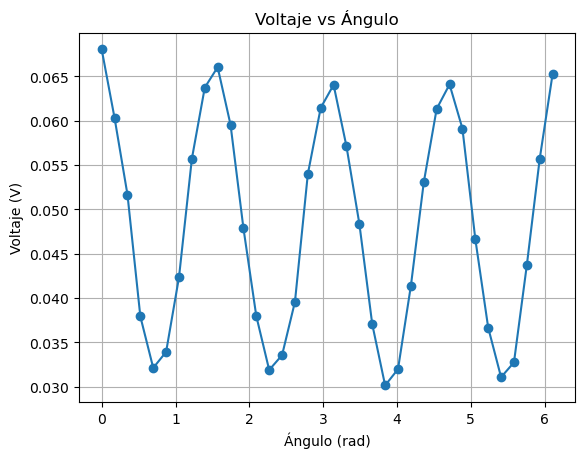

In [16]:
#we plot the data to see if it looks like a sinusoidal function, as we expect
plt.plot(theta_para, I_med_para, 'o-')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

In [17]:
# --- estimate S0 --- and normalize voltaje
# --- Identify peaks in the voltage data to select the mean as the normalization factor ---
peaks_volt = find_peaks(medicion['voltaje'])[0]
peaks_angle = theta_para[peaks_volt]
norm_number = I_med_para[peaks_volt].mean()
display(f'Normalization number: {norm_number}')

I_med_para = I_med_para / norm_number


'Normalization number: 0.0647176'

In [18]:

S0_para = np.max(I_med_para)
print(f'S0: {S0_para}')

S0: 1.0511761870032266


S0_para = 1.0511761870032266
S1 = 0.9676101102089255
S2 = -0.16095397980000245
S3 = 0.009266389197268502

Deltas:
d1 = 1.6074862179603464
d2 = 1.6772450288503058
d3 = 1.686368243535522
d4 = 1.6745540843702968

DOP = 0.9331920124582159


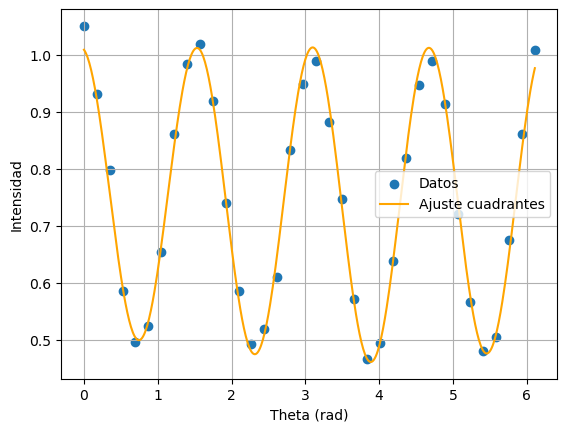

In [19]:
# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0_para/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return model(theta_para, S1, S2, S3, d1, d2, d3, d4) - I_med_para

# --- initial conditions ---
initial_guess = [
    0.1*S0_para,  # S1
    0.1*S0_para,  # S2
    0.1*S0_para,  # S3
    np.pi/2, np.pi/2, np.pi/2, np.pi/2  # deltas
]

# --- bounds (KEY for stability) ---
lower_bounds = [
    -S0_para, -S0_para, -S0_para,
    0, 0, 0, 0
]

upper_bounds = [
    S0_para, S0_para, S0_para,
    2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi
]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

print("S0_para =", S0_para)
print("S1 =", S1_fit)
print("S2 =", S2_fit)
print("S3 =", S3_fit)

print("\nDeltas:")
print("d1 =", d1_fit)
print("d2 =", d2_fit)
print("d3 =", d3_fit)
print("d4 =", d4_fit)

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0_para
print("\nDOP =", DOP)

# --- fitted curve ---
theta_fit = np.linspace(theta_para.min(), theta_para.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- graph ---
plt.scatter(theta_para, I_med_para, label="Datos")
plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

[ 0.92050231 -0.15311799  0.00881526]


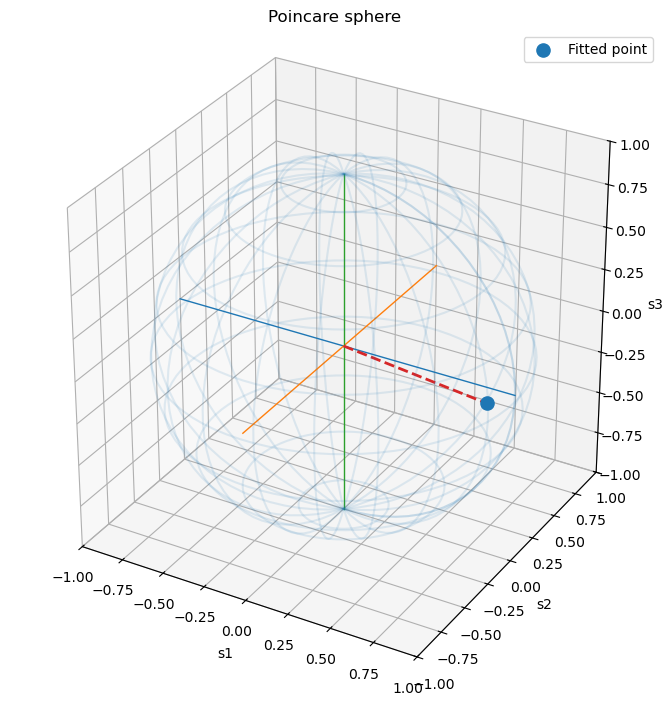

In [20]:
fig_new = plt.figure(figsize=(7, 7))
s_fit_para=np.array([S1_fit/S0_para, S2_fit/S0_para, S3_fit/S0_para]  )
print(s_fit_para)
ax_new = fig_new.add_subplot(111, projection='3d')
plot_poincare_sphere(ax_new,  s_fit_para)
plt.tight_layout()
plt.show()

# Comparison of both polarizations 

In [21]:
def plot_poincare_sphere(ax, s_points):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    # ejes
    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    # --- plot de múltiples puntos ---
    for i, s in enumerate(s_points):
        ax.scatter(s[0], s[1], s[2], s=90, label=f"Point {i+1}")
        ax.plot([0, s[0]], [0, s[1]], [0, s[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()

In [22]:
s1=np.array([-1. ,        -0.00681672,  0.21763307] )
s2=np.array([ 0.92050231, -0.15311799,  0.00881526] )
s3=np.array([-0.82727437,  0.67022515 , 0.02815319])

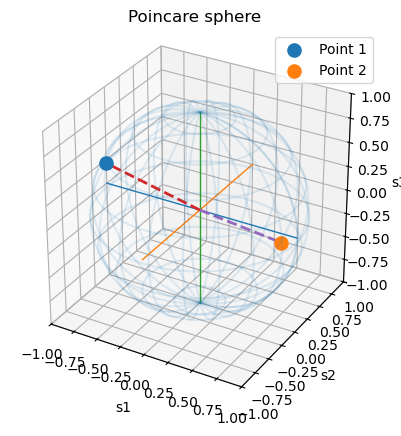

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plot_poincare_sphere(ax, [s1, s2])

plt.show()

# Errors an graphs

## Orthogonal

In [24]:
S0_orth=np.max(I_med_orth)

In [25]:
#errors


theta_err_orth = np.deg2rad(2)     

V_div=0.005 #V
V_full_scale = 8 * V_div  
res_err = V_full_scale / 256

I_err_orth = np.sqrt((0.03 * I_med_orth)**2 + res_err**2)
I_err_orth = np.abs(I_err_orth)



S0 = 0.014021599999999999
S1 = -0.014021599999999997 ± 0.00023583274726412886
S2 = -0.00024074507453927986 ± 0.00029801929307098177
S3 = -0.0006997447756012498 ± 0.001954109043786921

Deltas:
d1 = 3.9743776342887527 ± 0.1796337545291255
d2 = 3.9650587192015445 ± 0.2026079934898743
d3 = 3.243516753150437 ± 0.3810576808633324
d4 = 1.5707963267948966 ± 0.0

DOP = 1.0013916721965932 ± 0.018178859845657144


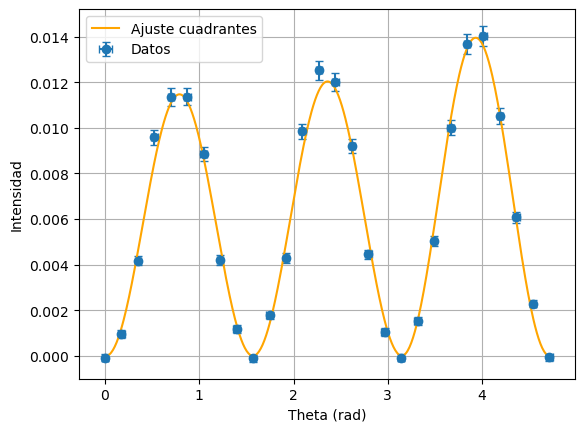

In [26]:

# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0_orth/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals con pesos ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return (model(theta_orth, S1, S2, S3, d1, d2, d3, d4) - I_med_orth) / I_err_orth

# --- initial conditions ---
initial_guess = [
    0.1*S0_orth,
    0.1*S0_orth,
    0.1*S0_orth,
    np.pi/2, np.pi/2, np.pi/2, np.pi/2
]

# --- bounds ---
lower_bounds = [-S0_orth, -S0_orth, -S0_orth, 0, 0, 0, 0]
upper_bounds = [ S0_orth,  S0_orth,  S0_orth, 2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

# --- errores de parámetros ---
J = result.jac
cov = np.linalg.pinv(J.T @ J) * np.sum(result.fun**2) / (len(I_med_orth) - len(result.x))
param_errors = np.sqrt(np.diag(cov))

S1_err, S2_err, S3_err, d1_err, d2_err, d3_err, d4_err = param_errors

# --- resultados ---
print("S0 =", S0_orth)
print(f"S1 = {S1_fit} ± {S1_err}")
print(f"S2 = {S2_fit} ± {S2_err}")
print(f"S3 = {S3_fit} ± {S3_err}")

print("\nDeltas:")
print(f"d1 = {d1_fit} ± {d1_err}")
print(f"d2 = {d2_fit} ± {d2_err}")
print(f"d3 = {d3_fit} ± {d3_err}")
print(f"d4 = {d4_fit} ± {d4_err}")

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0_orth

DOP_err = (1 / S0_orth) * np.sqrt(
    (S1_fit * S1_err)**2 +
    (S2_fit * S2_err)**2 +
    (S3_fit * S3_err)**2
) / np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2)

print(f"\nDOP = {DOP} ± {DOP_err}")

# --- fitted curve ---
theta_fit = np.linspace(theta_orth.min(), theta_orth.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- gráfico con errores ---
plt.errorbar(theta_orth, I_med_orth, yerr=I_err_orth, xerr=theta_err_orth,
             fmt='o', capsize=3, label="Datos")

plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

In [27]:
print("cond(JTJ) =", np.linalg.cond(J.T @ J))

cond(JTJ) = inf


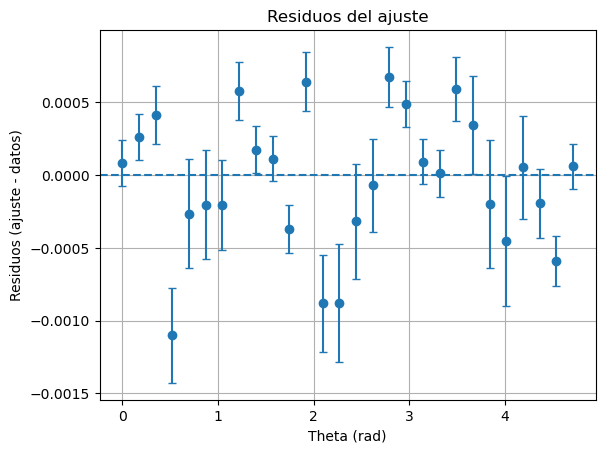

In [28]:
residuos = model(theta_orth, S1_fit, S2_fit, S3_fit,
                 d1_fit, d2_fit, d3_fit, d4_fit) - I_med_orth

plt.errorbar(theta_orth, residuos, yerr=I_err_orth, fmt='o', capsize=3)

plt.axhline(0, linestyle='--')

plt.xlabel("Theta (rad)")
plt.ylabel("Residuos (ajuste - datos)")
plt.title("Residuos del ajuste")

plt.grid()
plt.show()

In [29]:
# grados de libertad
N = len(I_med_orth)
p = len(result.x)
dof = N - p

# chi cuadrado
from scipy.stats import chi2
chi2_val = np.sum(result.fun**2)

# p-valor
p_value = 1 - chi2.cdf(chi2_val, dof)

print(f"Chi^2 = {chi2_val}")
print(f"grados de libertad = {dof}")
print(f"p-valor = {p_value}")

Chi^2 = 99.9315859923062
grados de libertad = 21
p-valor = 2.967515122520581e-12


In [30]:
# --- vector de Stokes normalizado (Poincaré) ---
s1_orth = S1_fit / S0_orth
s2_orth= S2_fit / S0_orth
s3_orth = S3_fit / S0_orth

# --- errores ---
s1_err_orth = S1_err / S0_orth
s2_err_orth = S2_err / S0_orth
s3_err_orth = S3_err / S0_orth

print("\nVector de Poincaré:")
print(f"s1 = {s1} ± {s1_err_orth}")
print(f"s2 = {s2} ± {s2_err_orth}")
print(f"s3 = {s3} ± {s3_err_orth}")


Vector de Poincaré:
s1 = [-1.         -0.00681672  0.21763307] ± 0.016819246538492674
s2 = [ 0.92050231 -0.15311799  0.00881526] ± 0.021254300013620542
s3 = [-0.82727437  0.67022515  0.02815319] ± 0.13936419836444636


## Parallel

In [31]:

theta_err_para = np.deg2rad(2)     

V_div=0.005 #V
V_full_scale = 8 * V_div  
res_err = V_full_scale / 256

I_err_para = np.sqrt((0.03 * I_med_para)**2 + res_err**2)
I_err_para = np.abs(I_err_para)


S0 = 1.0511761870032266
S1 = 0.9652086151514249 ± 0.01607569272877047
S2 = -0.15430125382588403 ± 0.019090352011122712
S3 = -0.013521797681728788 ± 0.05468154272081722

Deltas:
d1 = 1.6427101587056505 ± 0.0639233490990648
d2 = 1.6453118950164143 ± 0.06417454480798425
d3 = 1.7103529238512811 ± 0.06349286036240624
d4 = 1.6532252234453992 ± 0.06374392998021579

DOP = 0.9299657667402894 ± 0.015386384273468298


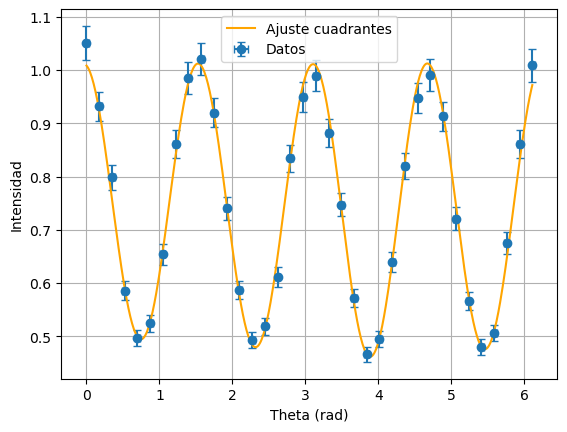

In [32]:

# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0_para/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals con pesos ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return (model(theta_para, S1, S2, S3, d1, d2, d3, d4) - I_med_para) / I_err_para

# --- initial conditions ---
initial_guess = [
    0.1*S0_para,
    0.1*S0_para,
    0.1*S0_para,
    np.pi/2, np.pi/2, np.pi/2, np.pi/2
]

# --- bounds ---
lower_bounds = [-S0_para, -S0_para, -S0_para, 0, 0, 0, 0]
upper_bounds = [ S0_para,  S0_para,  S0_para, 2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

# --- errores de parámetros ---
J = result.jac
cov = np.linalg.inv(J.T @ J) * np.sum(result.fun**2) / (len(I_med) - len(result.x))
param_errors = np.sqrt(np.diag(cov))

S1_err, S2_err, S3_err, d1_err, d2_err, d3_err, d4_err = param_errors

# --- resultados ---
print("S0 =", S0_para)
print(f"S1 = {S1_fit} ± {S1_err}")
print(f"S2 = {S2_fit} ± {S2_err}")
print(f"S3 = {S3_fit} ± {S3_err}")

print("\nDeltas:")
print(f"d1 = {d1_fit} ± {d1_err}")
print(f"d2 = {d2_fit} ± {d2_err}")
print(f"d3 = {d3_fit} ± {d3_err}")
print(f"d4 = {d4_fit} ± {d4_err}")

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0_para

DOP_err = (1 / S0_para) * np.sqrt(
    (S1_fit * S1_err)**2 +
    (S2_fit * S2_err)**2 +
    (S3_fit * S3_err)**2
) / np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2)

print(f"\nDOP = {DOP} ± {DOP_err}")

# --- fitted curve ---
theta_fit = np.linspace(theta_para.min(), theta_para.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- gráfico con errores ---
plt.errorbar(theta_para, I_med_para, yerr=I_err_para, xerr=theta_err_para,
             fmt='o', capsize=3, label="Datos")

plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

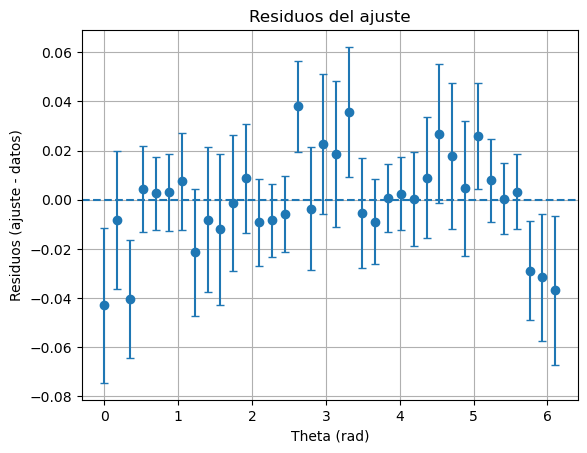

In [33]:
residuos = model(theta_para, S1_fit, S2_fit, S3_fit,
                 d1_fit, d2_fit, d3_fit, d4_fit) - I_med_para

plt.errorbar(theta_para, residuos, yerr=I_err_para, fmt='o', capsize=3)

plt.axhline(0, linestyle='--')

plt.xlabel("Theta (rad)")
plt.ylabel("Residuos (ajuste - datos)")
plt.title("Residuos del ajuste")

plt.grid()
plt.show()

In [34]:
# grados de libertad
N = len(I_med_para)
p = len(result.x)
dof = N - p

# chi cuadrado
from scipy.stats import chi2
chi2_val = np.sum(result.fun**2)

# p-valor
p_value = 1 - chi2.cdf(chi2_val, dof)

print(f"Chi^2 = {chi2_val}")
print(f"grados de libertad = {dof}")
print(f"p-valor = {p_value}")

Chi^2 = 22.437912386109215
grados de libertad = 29
p-valor = 0.801615044084736


In [35]:
# --- vector de Stokes normalizado (Poincaré) ---
s1_para = S1_fit / S0_para
s2_para = S2_fit / S0_para
s3_para = S3_fit / S0_para

# --- errores ---
s1_err_para = S1_err / S0_para
s2_err_para = S2_err / S0_para
s3_err_para = S3_err / S0_para

print("\nVector de Poincaré:")
print(f"s1 = {s1} ± {s1_err_para}")
print(f"s2 = {s2} ± {s2_err_para}")
print(f"s3 = {s3} ± {s3_err_para}")


Vector de Poincaré:
s1 = [-1.         -0.00681672  0.21763307] ± 0.015293052608621476
s2 = [ 0.92050231 -0.15311799  0.00881526] ± 0.018160944137772896
s3 = [-0.82727437  0.67022515  0.02815319] ± 0.05201938875414172


## Comparison with three points obteined

In [36]:
def plot_poincare_sphere(ax, s_points):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    # ejes
    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    # --- plot de múltiples puntos ---
    for i, s in enumerate(s_points):
        ax.scatter(s[0], s[1], s[2], s=90, label=f"Point {i+1}")
        ax.plot([0, s[0]], [0, s[1]], [0, s[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()

In [37]:
s1=np.array([-0.8152544692898802 ,         0.628603213018236,  -0.10498477333323827] )
s2=np.array([ 0.9182177405184538, -0.14678916733408842,  -0.012863420529279104] )
s3=np.array([-0.82727437,  0.67022515 , 0.02815319])

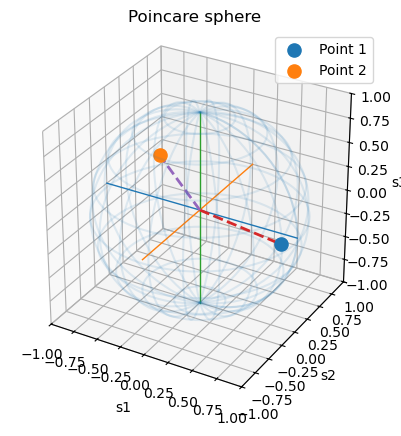

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plot_poincare_sphere(ax, [ s2, s3])

plt.show()

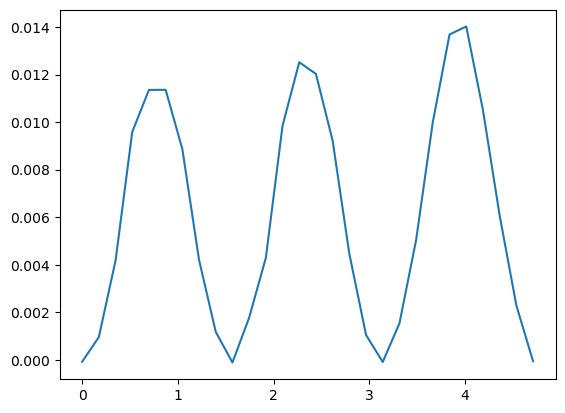

In [39]:
plt.plot(theta_orth,I_med_orth)

# Curve-fit - Orthogonal Axis

S0_orth = 0.014021599999999999
S1 = -0.014021599999999997 ± 0.00010810910777124514
S2 = -0.0002407457293427137 ± 0.0001366163227270346
S3 = -0.0006998166905361524 ± 0.0008957912597626067

Deltas:
d1 = 3.9743708359431618 ± 0.08234625825753913
d2 = 3.965066463114597 ± 0.0928787314066541
d3 = 3.243505862316694 ± 0.17468497807515412
d4 = 1.5707963267948966 ± 0.0

DOP = 1.001391928609679 ± 0.008333572101567085


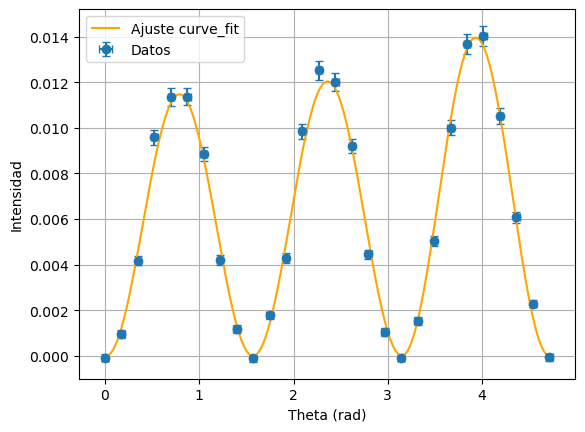

In [40]:

# same model we used before
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4


def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0_orth/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

#curve fit 

initial_guess = [
    0.1*S0_orth,
    0.1*S0_orth,
    0.1*S0_orth,
    np.pi/2, np.pi/2, np.pi/2, np.pi/2
]

lower_bounds = [-S0_orth, -S0_orth, -S0_orth, 0, 0, 0, 0]
upper_bounds = [ S0_orth,  S0_orth,  S0_orth, 2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi]

popt, pcov = curve_fit(
    model,
    theta_orth,
    I_med_orth,
    p0=initial_guess,
    sigma=I_err_orth,
    absolute_sigma=True,
    bounds=(lower_bounds, upper_bounds),maxfev=20000
)

#parameters
S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = popt

param_errors = np.sqrt(np.diag(pcov))
S1_err, S2_err, S3_err, d1_err, d2_err, d3_err, d4_err = param_errors


# results
print("S0_orth =", S0_orth)
print(f"S1 = {S1_fit} ± {S1_err}")
print(f"S2 = {S2_fit} ± {S2_err}")
print(f"S3 = {S3_fit} ± {S3_err}")

print("\nDeltas:")
print(f"d1 = {d1_fit} ± {d1_err}")
print(f"d2 = {d2_fit} ± {d2_err}")
print(f"d3 = {d3_fit} ± {d3_err}")
print(f"d4 = {d4_fit} ± {d4_err}")


# DOP
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0_orth

DOP_err = (1 / S0_orth) * np.sqrt(
    (S1_fit * S1_err)**2 +
    (S2_fit * S2_err)**2 +
    (S3_fit * S3_err)**2
) / np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2)

print(f"\nDOP = {DOP} ± {DOP_err}")


#Curve for graph
theta_fit = np.linspace(theta_orth.min(), theta_orth.max(), 500)
I_fit = model(theta_fit, *popt)


# graph
plt.errorbar(theta_orth, I_med_orth, yerr=I_err_orth, xerr=theta_err_orth,
             fmt='o', capsize=3, label="Datos")

plt.plot(theta_fit, I_fit, color="orange", label="Ajuste curve_fit")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

In [41]:
# grados de libertad
N = len(I_med_orth)
p = len(result.x)
dof = N - p

# chi cuadrado
from scipy.stats import chi2
chi2_val = np.sum(result.fun**2)

# p-valor
p_value = 1 - chi2.cdf(chi2_val, dof)

print(f"Chi^2 = {chi2_val}")
print(f"grados de libertad = {dof}")
print(f"p-valor = {p_value}")

Chi^2 = 22.437912386109215
grados de libertad = 21
p-valor = 0.3746627252767083


In [42]:
# --- vector de Stokes normalizado (Poincaré) ---
s1_orth = S1_fit / S0_orth
s2_orth = S2_fit / S0_orth
s3_orth = S3_fit / S0_orth

# --- errores ---
s1_err_orth = S1_err / S0_orth
s2_err_orth = S2_err / S0_orth
s3_err_orth = S3_err / S0_orth

print("\nVector de Poincaré:")
print(f"s1 = {s1_orth} ± {s1_err_orth}")
print(f"s2 = {s2_orth} ± {s2_err_orth}")
print(f"s3 = {s3_orth} ± {s3_err_orth}")



Vector de Poincaré:
s1 = -0.9999999999999999 ± 0.007710183414962996
s2 = -0.017169633233205462 ± 0.009743276282808995
s3 = -0.04990990261711591 ± 0.06388652220592562


In [43]:
s_curf_orth=np.array([s1_orth,s2_orth,s3_orth])

# Curve FIt - Parallel Axis

S0_orth = 1.0511761870032266
S1 = 0.9652086158172117 ± 0.01555206713368515
S2 = -0.15430125348630674 ± 0.018468531336534012
S3 = -0.013521803247510608 ± 0.05290042879806719

Deltas:
d1 = 1.6427101652765976 ± 0.06184120641838105
d2 = 1.6453118891246539 ± 0.062084219773752176
d3 = 1.7103529301220253 ± 0.06142473921488043
d4 = 1.653225217529391 ± 0.06166763081406797

DOP = 0.9299657673879099 ± 0.014885211192400423


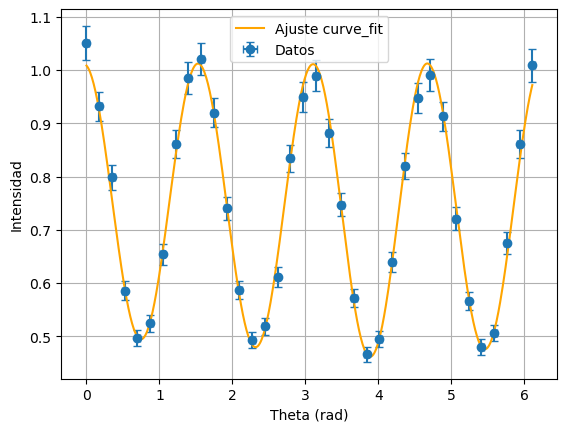

In [44]:

# same model we used before
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4


def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0_para/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

#curve fit 

initial_guess = [
    0.1*S0_para,
    0.1*S0_para,
    0.1*S0_para,
    np.pi/2, np.pi/2, np.pi/2, np.pi/2
]

lower_bounds = [-S0_para, -S0_para, -S0_para, 0, 0, 0, 0]
upper_bounds = [ S0_para,  S0_para,  S0_para, 2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi]

popt, pcov = curve_fit(
    model,
    theta_para,
    I_med_para,
    p0=initial_guess,
    sigma=I_err_para,
    absolute_sigma=True,
    bounds=(lower_bounds, upper_bounds),maxfev=20000
)

#parameters
S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = popt

param_errors = np.sqrt(np.diag(pcov))
S1_err, S2_err, S3_err, d1_err, d2_err, d3_err, d4_err = param_errors


# results
print("S0_orth =", S0_para)
print(f"S1 = {S1_fit} ± {S1_err}")
print(f"S2 = {S2_fit} ± {S2_err}")
print(f"S3 = {S3_fit} ± {S3_err}")

print("\nDeltas:")
print(f"d1 = {d1_fit} ± {d1_err}")
print(f"d2 = {d2_fit} ± {d2_err}")
print(f"d3 = {d3_fit} ± {d3_err}")
print(f"d4 = {d4_fit} ± {d4_err}")


# DOP
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0_para

DOP_err = (1 / S0_para) * np.sqrt(
    (S1_fit * S1_err)**2 +
    (S2_fit * S2_err)**2 +
    (S3_fit * S3_err)**2
) / np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2)

print(f"\nDOP = {DOP} ± {DOP_err}")


#Curve for graph
theta_fit = np.linspace(theta_para.min(), theta_para.max(), 500)
I_fit = model(theta_fit, *popt)


# graph
plt.errorbar(theta_para, I_med_para, yerr=I_err_para, xerr=theta_err_para,
             fmt='o', capsize=3, label="Datos")

plt.plot(theta_fit, I_fit, color="orange", label="Ajuste curve_fit")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

In [45]:
# grados de libertad
N = len(I_med_para)
p = len(result.x)
dof = N - p

# chi cuadrado
from scipy.stats import chi2
chi2_val = np.sum(result.fun**2)

# p-valor
p_value = 1 - chi2.cdf(chi2_val, dof)

print(f"Chi^2 = {chi2_val}")
print(f"grados de libertad = {dof}")
print(f"p-valor = {p_value}")

Chi^2 = 22.437912386109215
grados de libertad = 29
p-valor = 0.801615044084736


In [46]:
# --- vector de Stokes normalizado (Poincaré) ---
s1_para = S1_fit / S0_para
s2_para = S2_fit / S0_para
s3_para = S3_fit / S0_para

# --- errores ---
s1_err_para = S1_err / S0_para
s2_err_para = S2_err / S0_para
s3_err_para = S3_err / S0_para

print("\nVector de Poincaré:")
print(f"s1 = {s1_para} ± {s1_err_para}")
print(f"s2 = {s2_para} ± {s2_err_para}")
print(f"s3 = {s3_para} ± {s3_err_para}")


Vector de Poincaré:
s1 = 0.9182177333838795 ± 0.014794919563410367
s2 = -0.14678914476382932 ± 0.017569396610082572
s3 = -0.01286349844554565 ± 0.05032498781092043


In [47]:
 0.9299657673879099+4*0.014885211192400423

0.9895066121575116

In [56]:
s_curf_para=np.array([s1_para,s2_para,s3_para])
print(s_curf_para)

[ 0.91821773 -0.14678914 -0.0128635 ]


## Another Comparison

In [49]:
def plot_poincare_sphere(ax, s1, s2):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    # ejes
    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    # --- vector 1 ---
    ax.scatter(s1[0], s1[1], s1[2], s=90, label="Orthogonal")
    ax.plot([0, s1[0]], [0, s1[1]], [0, s1[2]], "--", lw=2)

    # --- vector 2 ---
    ax.scatter(s2[0], s2[1], s2[2], s=90, label="Parallel")
    ax.plot([0, s2[0]], [0, s2[1]], [0, s2[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()

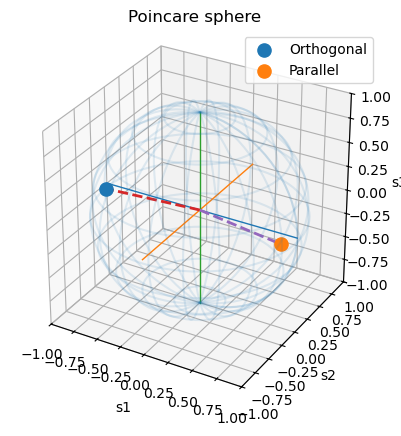

In [50]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
s2=s_curf_para
s1=s_curf_orth
plot_poincare_sphere(ax, s1,s2)
plt.ion()
plt.show()

In [51]:
print(np.linalg.norm(s1), np.linalg.norm(s2))

1.001391928609679 0.9299657673879099


In [52]:
#To keep comparing those vectores, we calculate de angle between them to see how much ortogonality they have
angle = np.arccos(np.clip(np.dot(s1, s2), -1, 1))
angle_deg = np.degrees(angle)


print("Ángulo =", angle_deg, "grados")

Ángulo = 156.21359604193273 grados


In [53]:
ortogonalidad = -np.dot(s1, s2)
print("Grado de ortogonalidad =", ortogonalidad)

Grado de ortogonalidad = 0.9150554016509359


### 3d sphere

In [54]:
def plot_poincare_sphere(ax, s1, s2):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    # ejes
    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    # --- vector 1 ---
    ax.scatter(s1[0], s1[1], s1[2], s=90, label="Orthogonal")
    ax.plot([0, s1[0]], [0, s1[1]], [0, s1[2]], "--", lw=2)

    # --- vector 2 ---
    ax.scatter(s2[0], s2[1], s2[2], s=90, label="Parallel")
    ax.plot([0, s2[0]], [0, s2[1]], [0, s2[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()

In [55]:
import matplotlib
matplotlib.use('TkAgg')

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

s1=np.array([-0.81525447,  0.62860321, -0.10498477])
s2=np.array([ 0.91821774 ,-0.14678917 ,-0.01286342])

plot_poincare_sphere(ax, s1, s2)

plt.show()